<a href="https://colab.research.google.com/github/Nikhil5566/EDA-Repo/blob/main/Wind_%26_Solar_Energy_Production_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Wind & Solar Energy Production Dataset

# About the dataset and insight


### Data Analysis Key Findings

*   **Feature Engineering**: Additional time-based features (`Year`, `Week_of_Year`, `Is_Weekend`) were successfully extracted, enabling more granular temporal analysis beyond just 'Date' and 'Day\_Name'.
*   **Source Distribution**: 'Wind' and 'Solar' are the dominant energy sources, with 42,484 and 9,378 entries respectively. The 'Mixed' source, with only 2 entries, was found to be statistically insignificant and was excluded from further analysis to avoid skewing results.
*   **Weekly Production Patterns**: Average daily energy production for both Wind and Solar generally remains relatively consistent across different days of the week, suggesting that weekly human activity patterns have a limited direct impact on average generation capacity.
*   **Seasonal Production Trends**: Solar production peaks in Summer and is lowest in Winter, directly correlating with solar irradiance. Conversely, Wind production shows higher averages in Winter and Fall, likely due to stronger and more consistent wind patterns during these seasons.
*   **Production Distribution and Outliers**:
    *   **Wind energy** exhibits a wider distribution of production values, indicating more variability, and generally maintains higher median production across all seasons, particularly in Winter.
    *   **Solar energy** shows a narrower production distribution, especially outside of summer months, and its overall production is notably lower compared to wind, with a distinct peak in Summer.
    *   Both energy sources display potential outliers, especially at higher production values, which is typical for energy generation datasets during optimal conditions.

### Insights or Next Steps

*   The distinct daily, weekly, and seasonal patterns for Wind and Solar energy production are critical for effective grid management, energy forecasting, and optimizing energy storage strategies.
*   Future analysis could explore the correlation between production data and specific weather parameters (e.g., wind speed, cloud cover, temperature) to build more predictive models and better understand the root causes of production variability and outliers.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Installing Kaggle API
!pip install -q kaggle

# Uploading kaggle.json
from google.colab import files
files.upload()

# Moving kaggle.json to ~/.kaggle/
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Downloading the dataset using Kaggle API
!kaggle datasets download -d ahmeduzaki/wind-and-solar-energy-production-dataset

# Unziping the downloaded file
!unzip wind-and-solar-energy-production-dataset.zip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/ahmeduzaki/wind-and-solar-energy-production-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
  0% 0.00/386k [00:00<?, ?B/s]
100% 386k/386k [00:00<00:00, 256MB/s]
Archive:  wind-and-solar-energy-production-dataset.zip
  inflating: Energy Production Dataset.csv  


In [3]:
df = pd.read_csv('Energy Production Dataset.csv')
df.head(11)

,Date,Start_Hour,End_Hour,Source,Day_of_Year,Day_Name,Month_Name,Season,Production
0,11/30/2025,21,22,Wind,334,Sunday,November,Fall,5281
1,11/30/2025,18,19,Wind,334,Sunday,November,Fall,3824
2,11/30/2025,16,17,Wind,334,Sunday,November,Fall,3824
3,11/30/2025,23,0,Wind,334,Sunday,November,Fall,6120
4,11/30/2025,6,7,Wind,334,Sunday,November,Fall,4387
5,11/30/2025,4,5,Wind,334,Sunday,November,Fall,4231
6,11/30/2025,5,6,Wind,334,Sunday,November,Fall,4365
7,11/30/2025,8,9,Wind,334,Sunday,November,Fall,4801
8,11/30/2025,12,13,Wind,334,Sunday,November,Fall,7737
9,11/30/2025,15,16,Wind,334,Sunday,November,Fall,5584


In [4]:
df.tail(11)

,Date,Start_Hour,End_Hour,Source,Day_of_Year,Day_Name,Month_Name,Season,Production
51853,1/1/2020,8,9,Wind,1,Wednesday,January,Winter,1831
51854,1/1/2020,16,17,Wind,1,Wednesday,January,Winter,1000
51855,1/1/2020,5,6,Wind,1,Wednesday,January,Winter,2583
51856,1/1/2020,1,2,Wind,1,Wednesday,January,Winter,2932
51857,1/1/2020,0,1,Wind,1,Wednesday,January,Winter,3542
51858,1/1/2020,3,4,Wind,1,Wednesday,January,Winter,2761
51859,1/1/2020,4,5,Wind,1,Wednesday,January,Winter,2708
51860,1/1/2020,18,19,Wind,1,Wednesday,January,Winter,1077
51861,1/1/2020,7,8,Wind,1,Wednesday,January,Winter,2077
51862,1/1/2020,14,15,Solar,1,Wednesday,January,Winter,1783


In [5]:
df.shape

(51864, 9)

In [6]:
df.columns

Index(['Date', 'Start_Hour', 'End_Hour', 'Source', 'Day_of_Year', 'Day_Name',
       'Month_Name', 'Season', 'Production'],
      dtype='object')

In [7]:
df.dtypes

,0
Date,object
Start_Hour,int64
End_Hour,int64
Source,object
Day_of_Year,int64
Day_Name,object
Month_Name,object
Season,object
Production,int64


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51864 entries, 0 to 51863
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Date         51864 non-null  object
 1   Start_Hour   51864 non-null  int64 
 2   End_Hour     51864 non-null  int64 
 3   Source       51864 non-null  object
 4   Day_of_Year  51864 non-null  int64 
 5   Day_Name     51864 non-null  object
 6   Month_Name   51864 non-null  object
 7   Season       51864 non-null  object
 8   Production   51864 non-null  int64 
dtypes: int64(4), object(5)
memory usage: 3.6+ MB


In [9]:
df.describe(include = 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Date,51864,2161,10/27/2024,25,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Start_Hour,51864.0,NaN,NaN,NaN,11.5,6.922253,0.0,5.75,11.5,17.25,23.0
End_Hour,51864.0,NaN,NaN,NaN,11.5,6.922253,0.0,5.75,11.5,17.25,23.0
Source,51864,3,Wind,42484,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Day_of_Year,51864.0,NaN,NaN,NaN,180.798415,104.291387,1.0,91.0,181.0,271.0,366.0
Day_Name,51864,7,Sunday,7416,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Month_Name,51864,12,October,4470,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Season,51864,4,Summer,13248,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Production,51864.0,NaN,NaN,NaN,6215.069933,3978.364965,58.0,3111.0,5372.0,8501.0,23446.0


In [19]:
df.isnull().sum()

,0
Date,0
Start_Hour,0
End_Hour,0
Source,0
Day_of_Year,0
Day_Name,0
Month_Name,0
Season,0
Production,0


In [21]:
df.duplicated().sum()

np.int64(0)

### Time Series Analysis and Source Comparison

Let's visualize the energy production over time, and compare the output from 'Wind' and 'Solar' sources.

In [14]:
df['Date'] = pd.to_datetime(df['Date'])

#### Daily Total Production Over Time

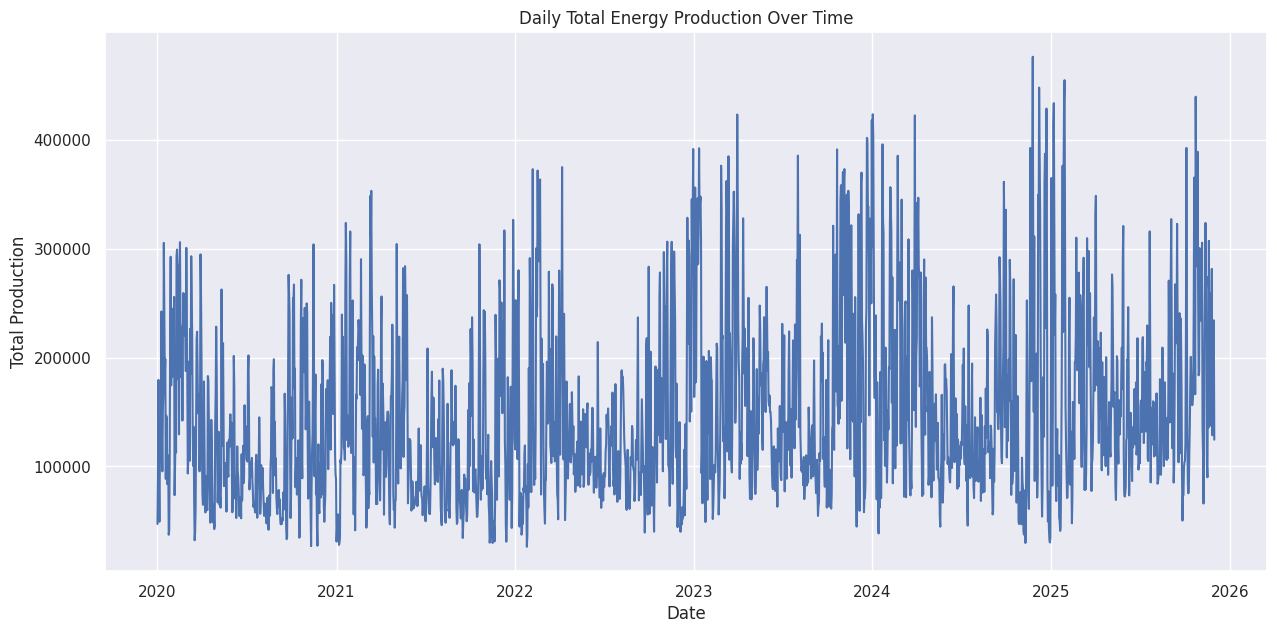

In [15]:
daily_production = df.groupby('Date')['Production'].sum().reset_index()

plt.figure(figsize=(15, 7))
sns.lineplot(data=daily_production, x='Date', y='Production')
plt.title('Daily Total Energy Production Over Time')
plt.xlabel('Date')
plt.ylabel('Total Production')
plt.grid(True)
plt.show()

#### Average Hourly Production by Source

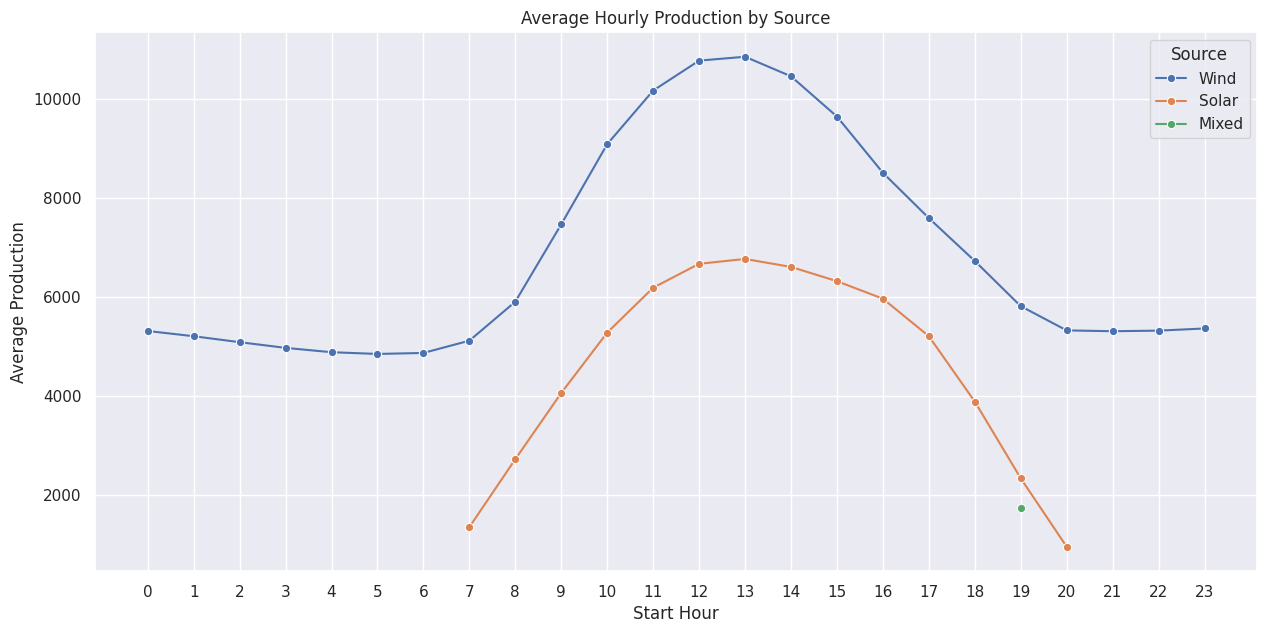

In [16]:
hourly_production_by_source = df.groupby(['Start_Hour', 'Source'])['Production'].mean().reset_index()

plt.figure(figsize=(15, 7))
sns.lineplot(data=hourly_production_by_source, x='Start_Hour', y='Production', hue='Source', marker='o')
plt.title('Average Hourly Production by Source')
plt.xlabel('Start Hour')
plt.ylabel('Average Production')
plt.xticks(range(24)) # Ensure all hours are displayed
plt.grid(True)
plt.show()

#### Monthly Average Production by Source

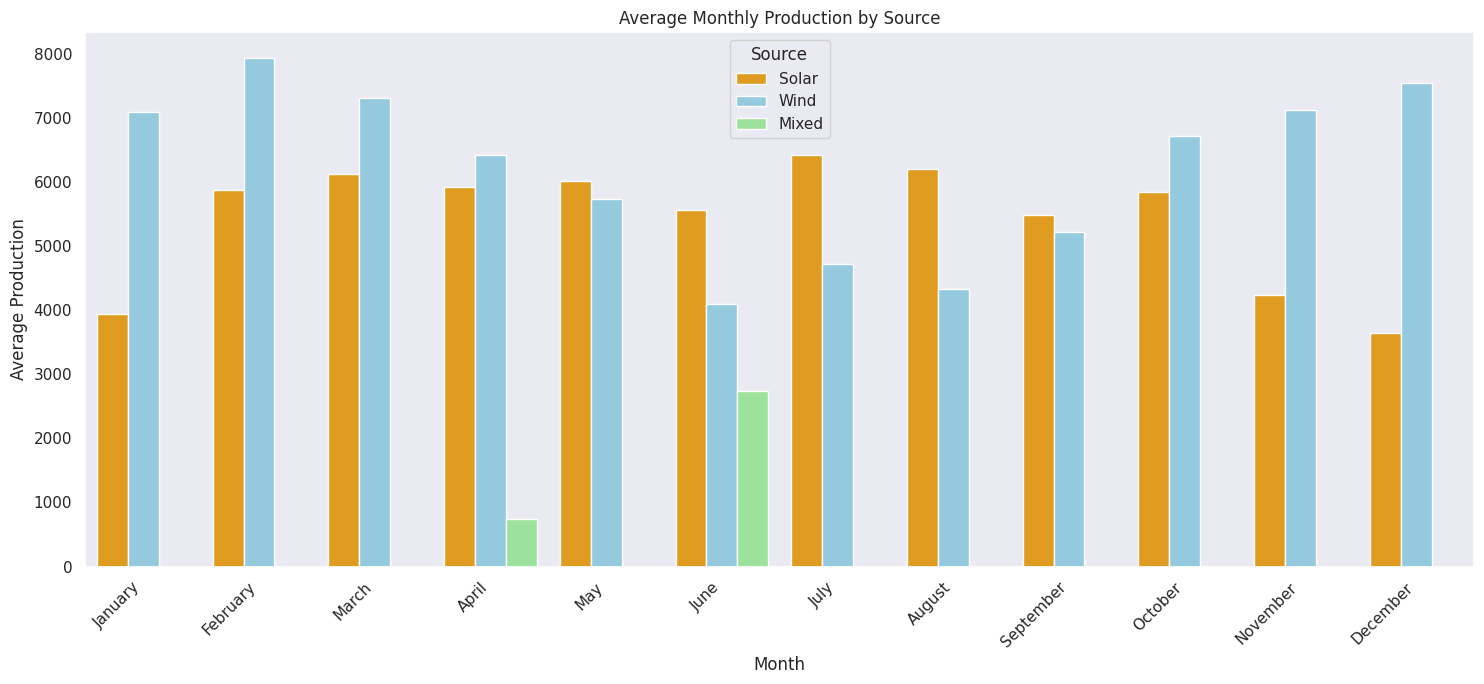

In [18]:
monthly_production_by_source = df.groupby(['Month_Name', 'Source'])['Production'].mean().reset_index()

# Order months correctly for plotting
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
monthly_production_by_source['Month_Name'] = pd.Categorical(monthly_production_by_source['Month_Name'], categories=month_order, ordered=True)
monthly_production_by_source = monthly_production_by_source.sort_values('Month_Name')

plt.figure(figsize=(15, 7))
sns.barplot(data=monthly_production_by_source, x='Month_Name', y='Production', hue='Source', palette={'Wind': 'skyblue', 'Solar': 'orange', 'Mixed': 'lightgreen'})
plt.title('Average Monthly Production by Source')
plt.xlabel('Month')
plt.ylabel('Average Production')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# Univariate Analysis

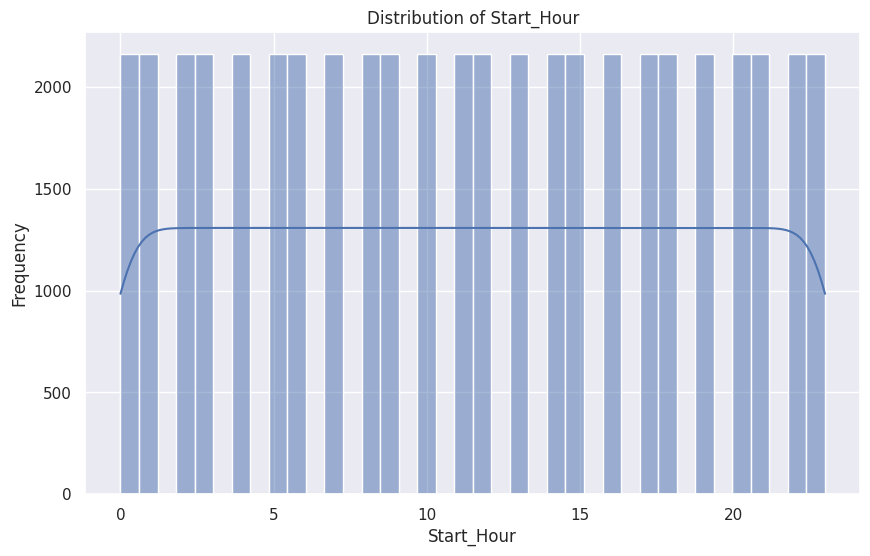

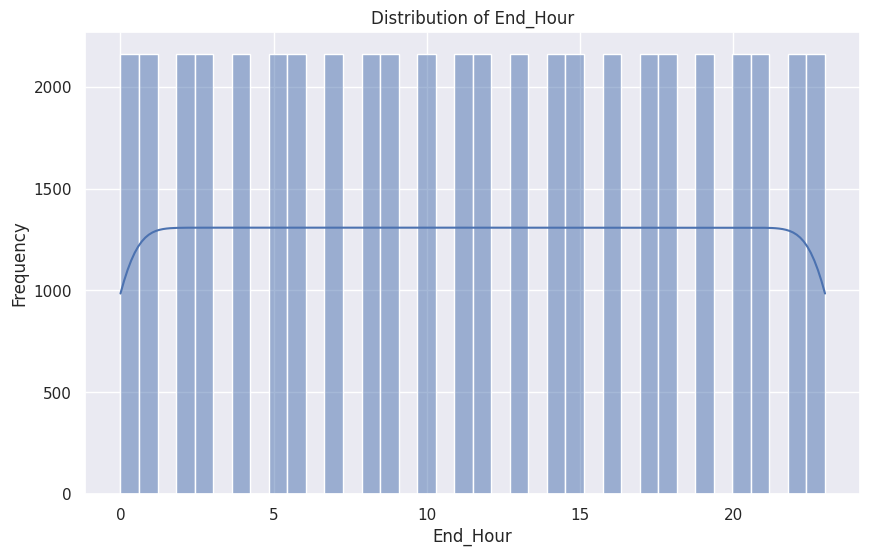

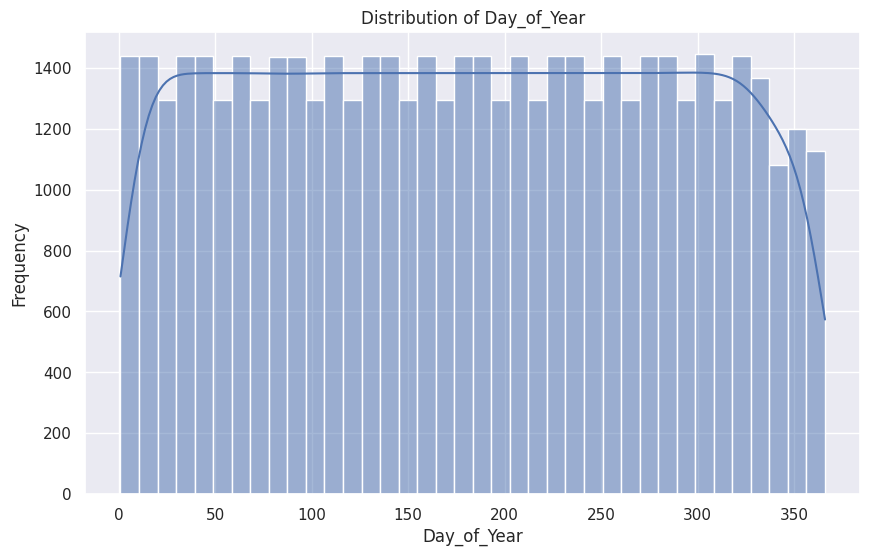

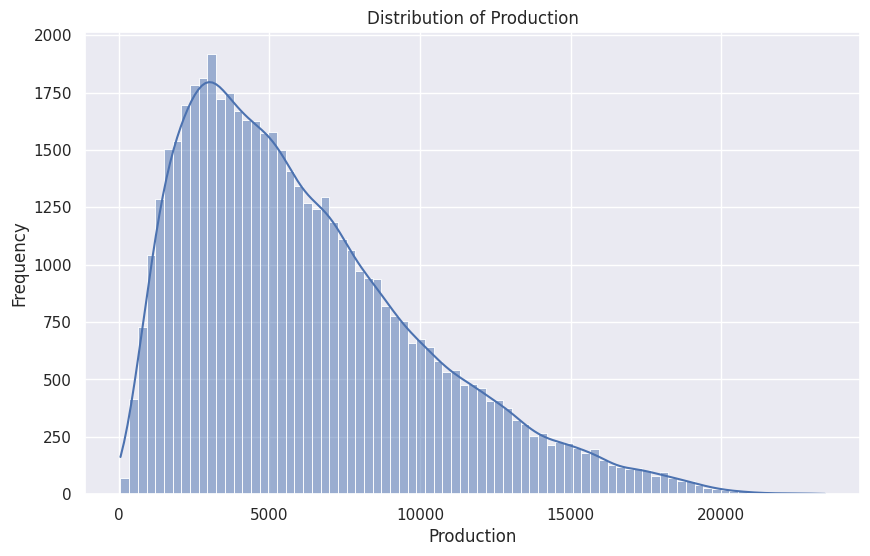

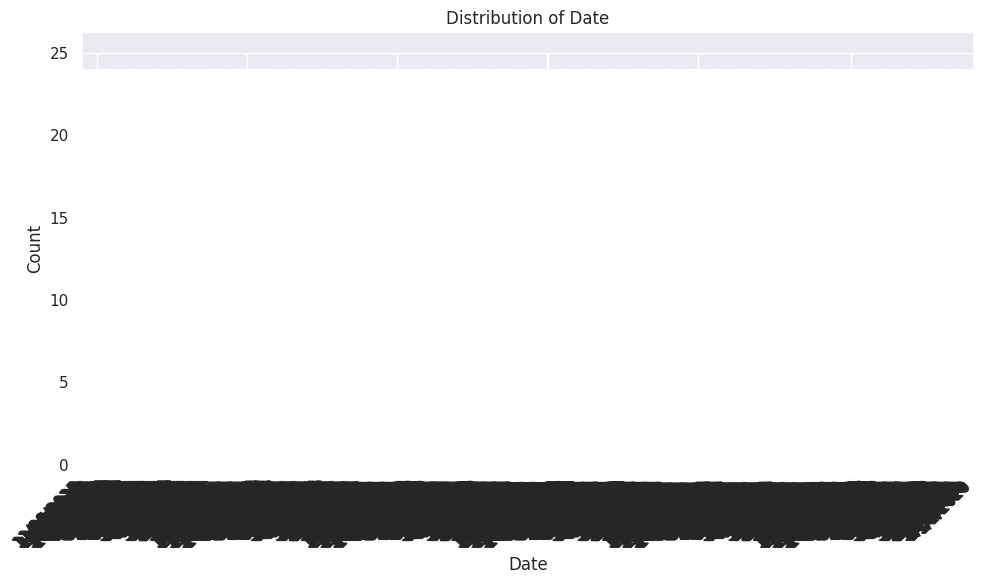

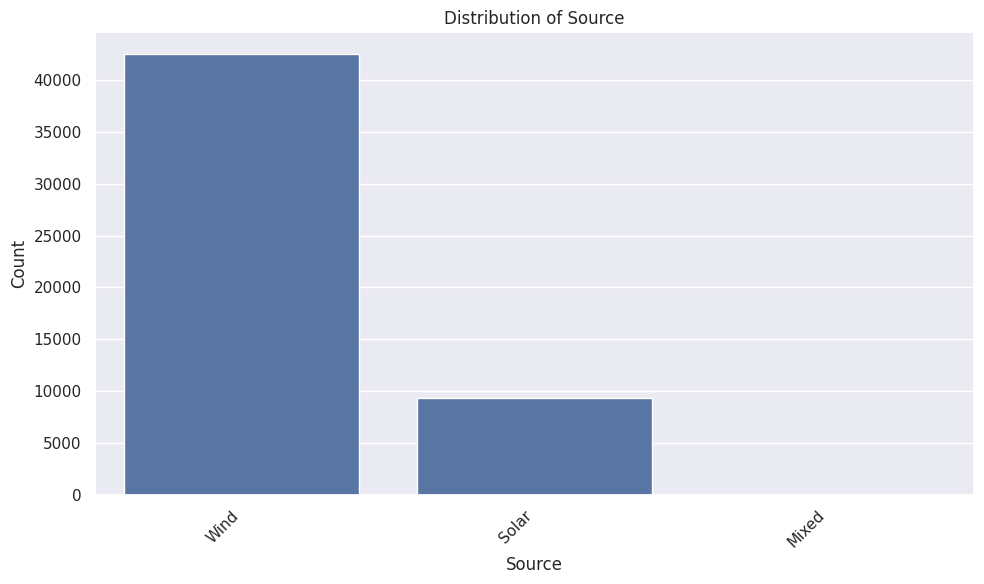

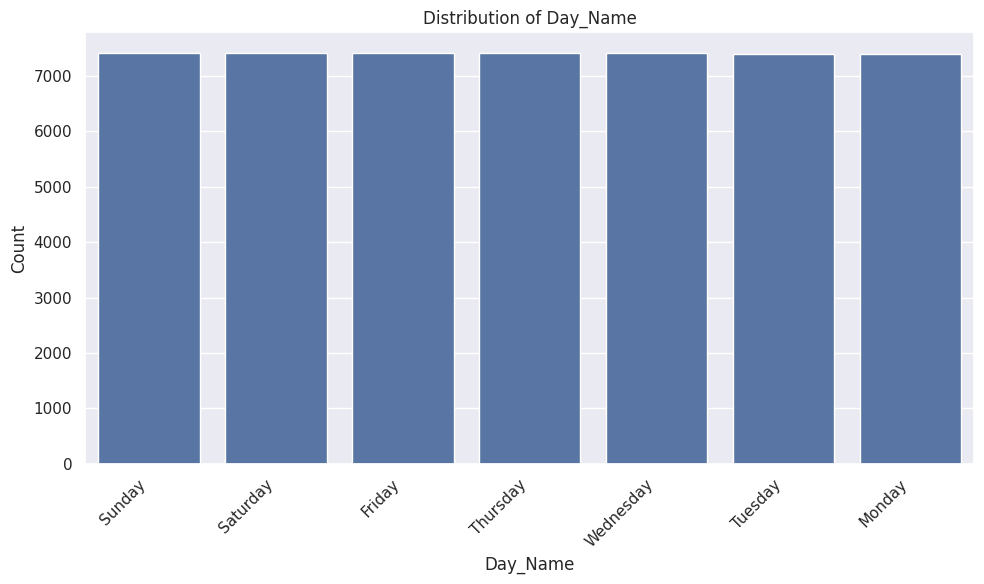

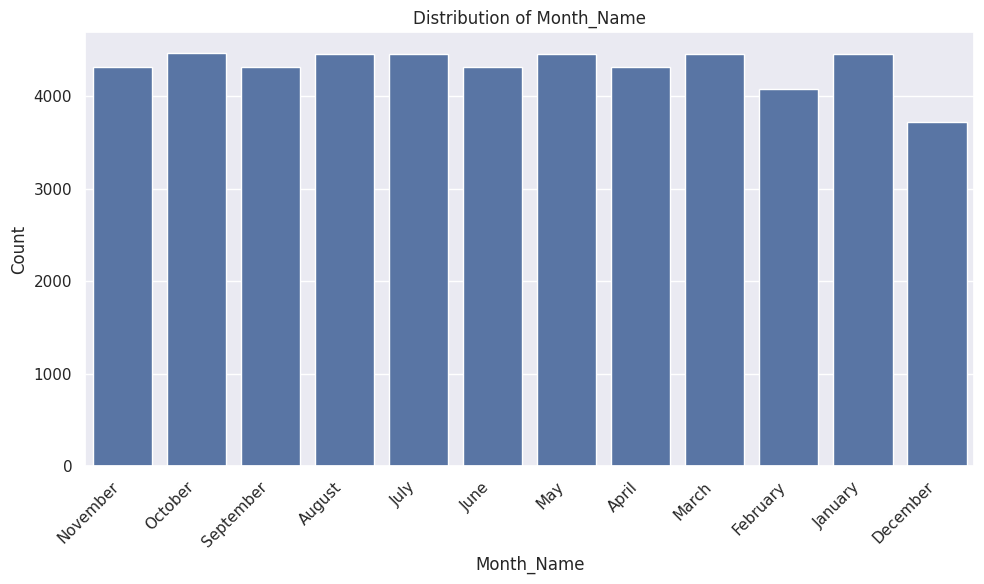

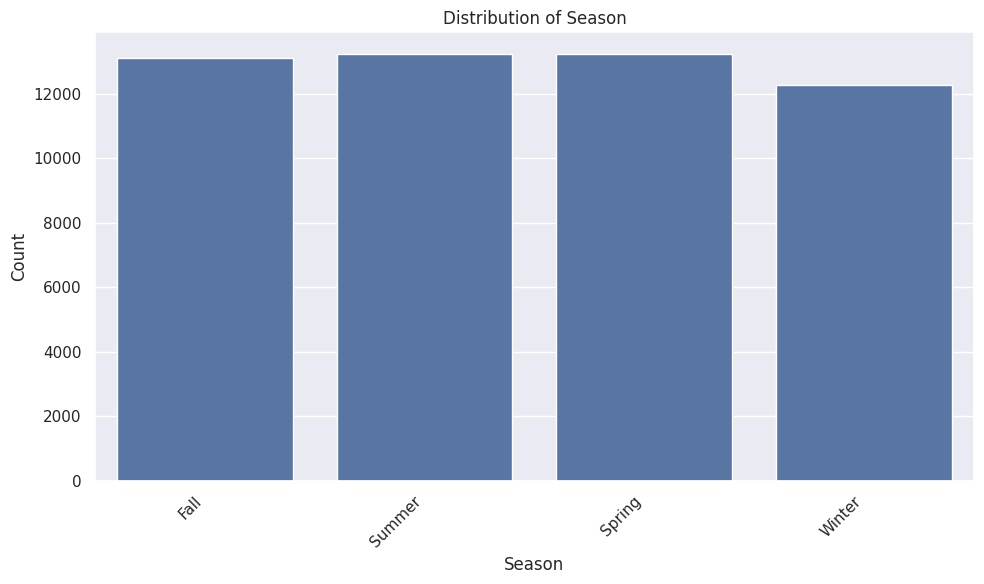

Value counts for Date:
Date
10/27/2024    25
10/31/2021    25
10/30/2022    25
10/26/2025    25
10/29/2023    25
              ..
3/28/2021     23
3/27/2022     23
3/26/2023     23
3/31/2024     23
3/30/2025     23
Name: count, Length: 2161, dtype: int64

Value counts for Source:
Source
Wind     42484
Solar     9378
Mixed        2
Name: count, dtype: int64

Value counts for Day_Name:
Day_Name
Sunday       7416
Saturday     7416
Friday       7416
Thursday     7416
Wednesday    7416
Tuesday      7392
Monday       7392
Name: count, dtype: int64

Value counts for Month_Name:
Month_Name
October      4470
August       4464
May          4464
July         4464
January      4464
March        4458
September    4320
November     4320
April        4320
June         4320
February     4080
December     3720
Name: count, dtype: int64

Value counts for Season:
Season
Summer    13248
Spring    13242
Fall      13110
Winter    12264
Name: count, dtype: int64



In [10]:
# Getting a list of numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterating through numerical columns and create histograms
for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# Getting a list of categorical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Iterate through categorical columns and create countplots
for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=col)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# We can also use value_counts for a quick look at categorical data distribution
for col in categorical_cols:
    print(f"Value counts for {col}:\n{df[col].value_counts()}\n")

# Bivariate Analysis

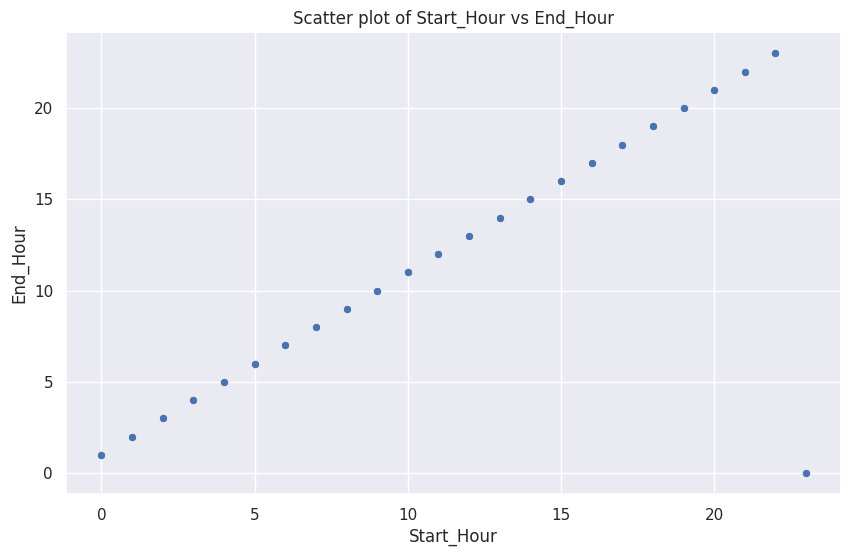

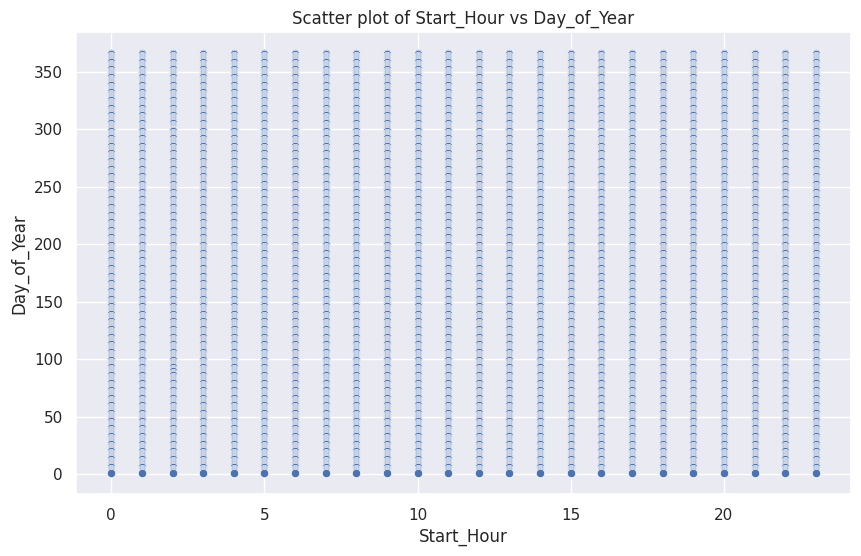

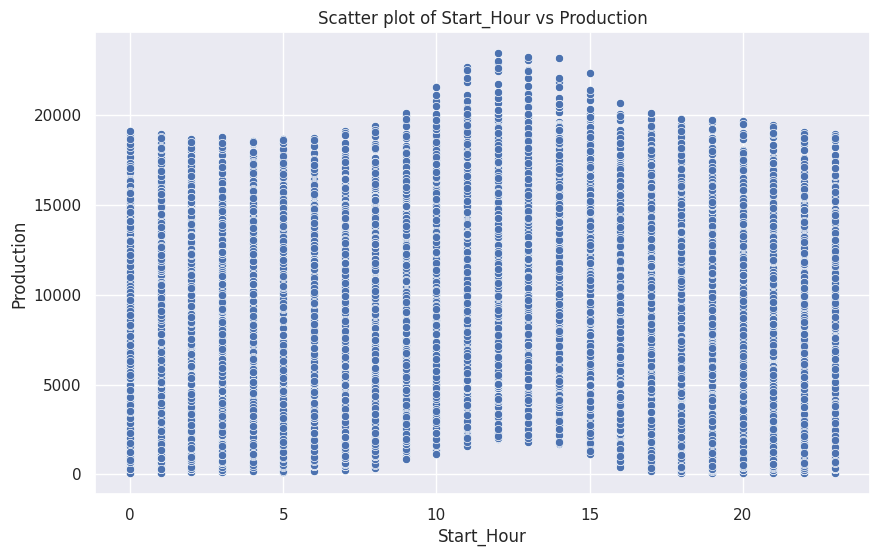

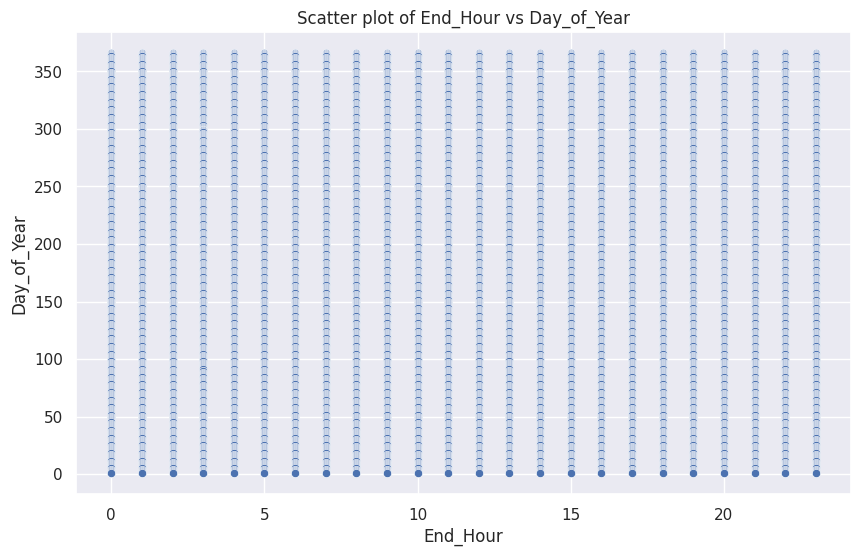

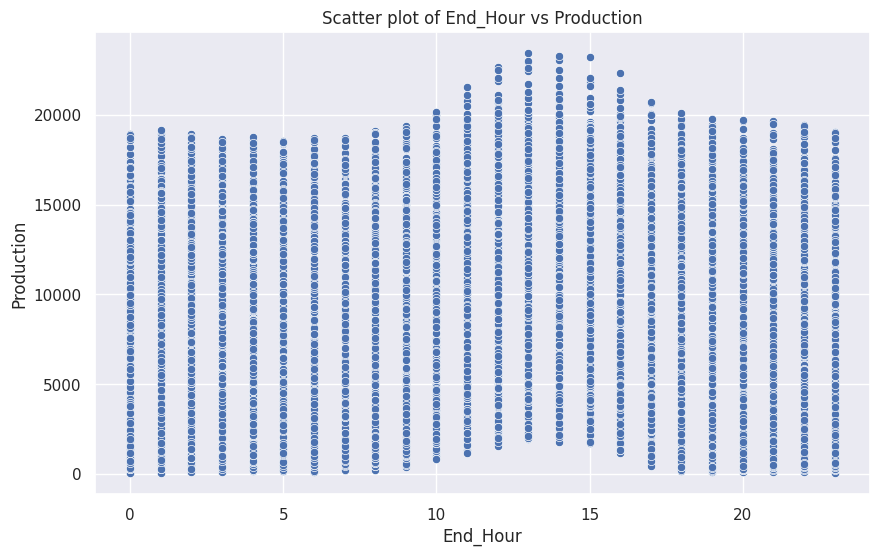

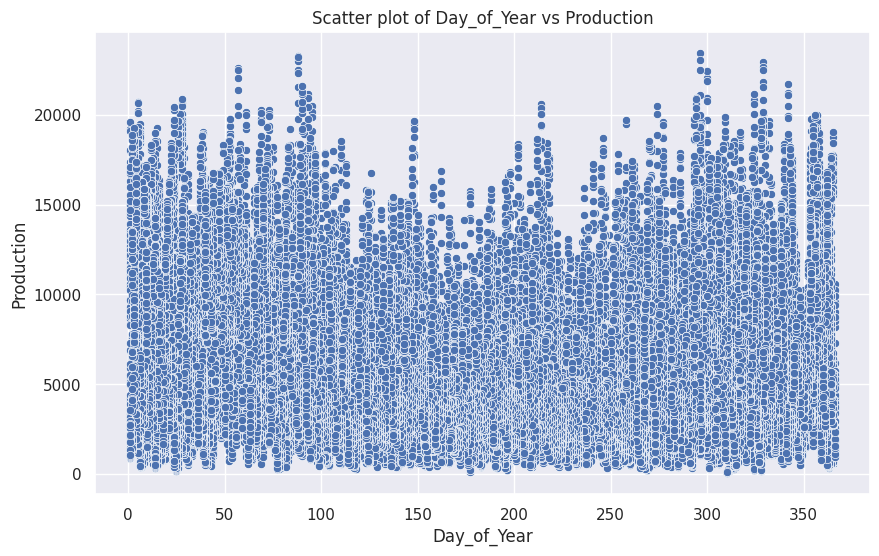

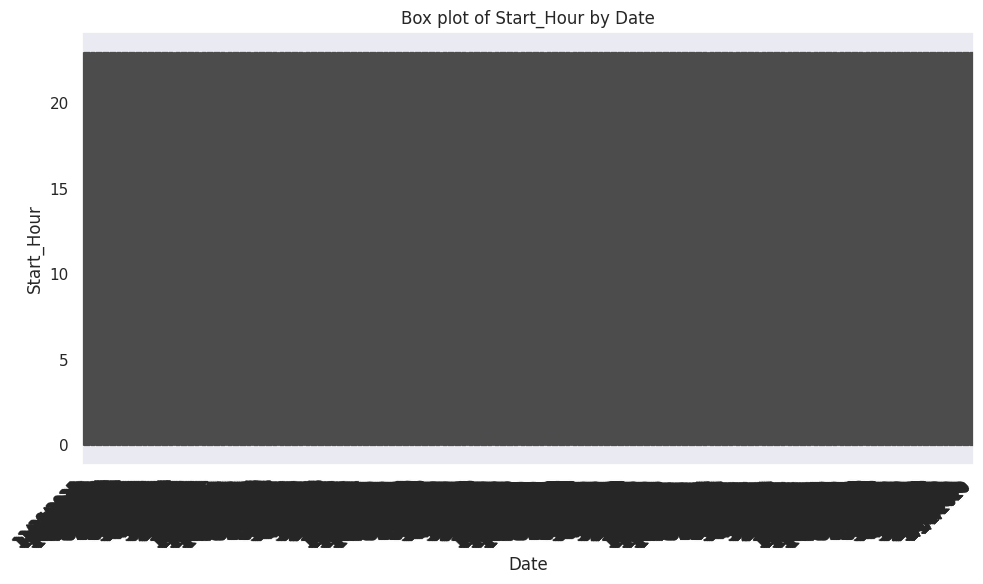

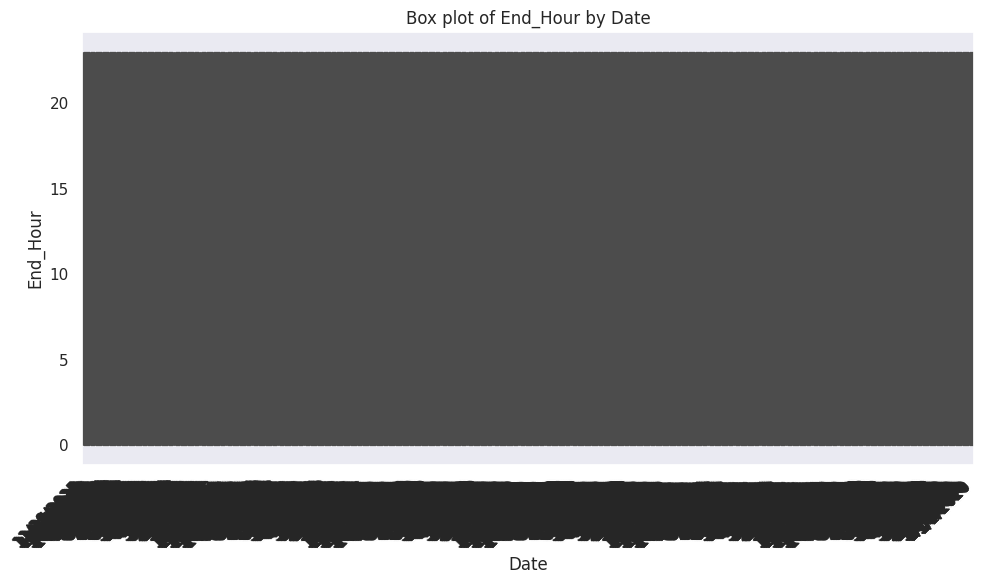

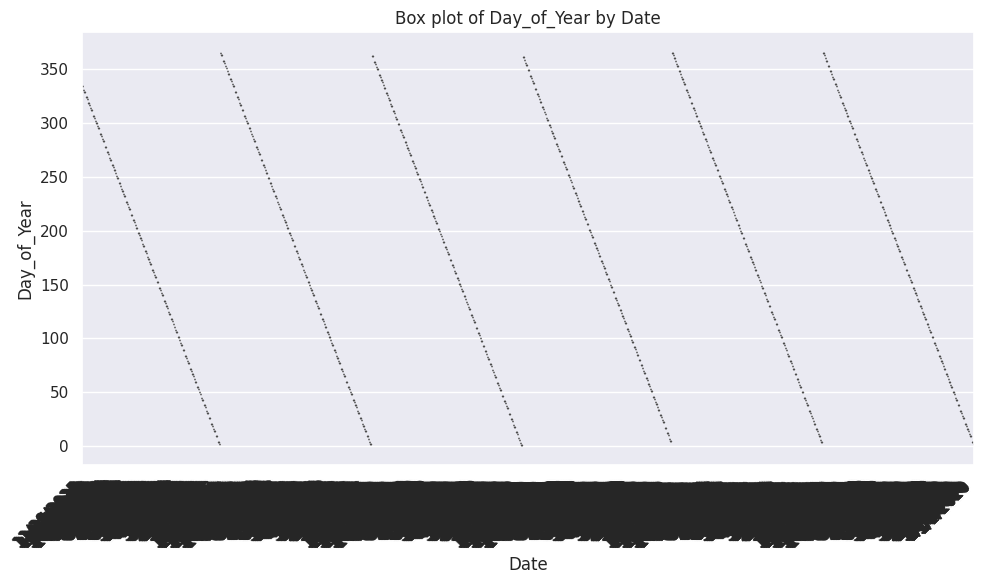

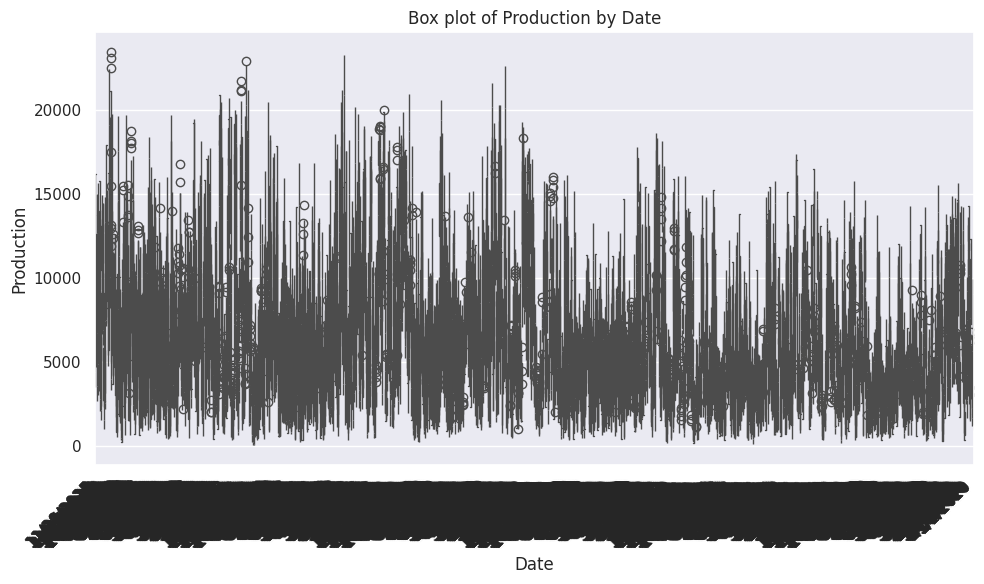

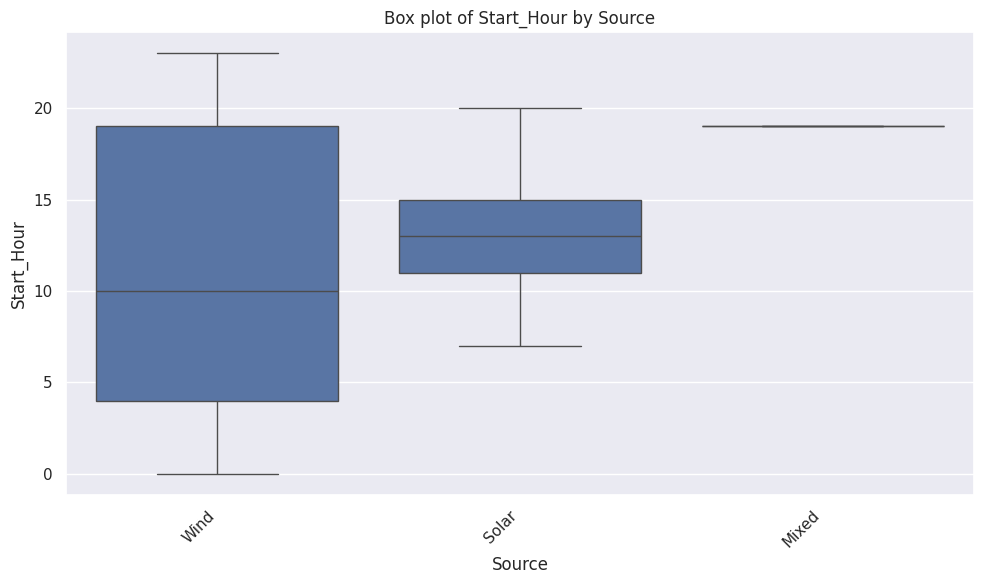

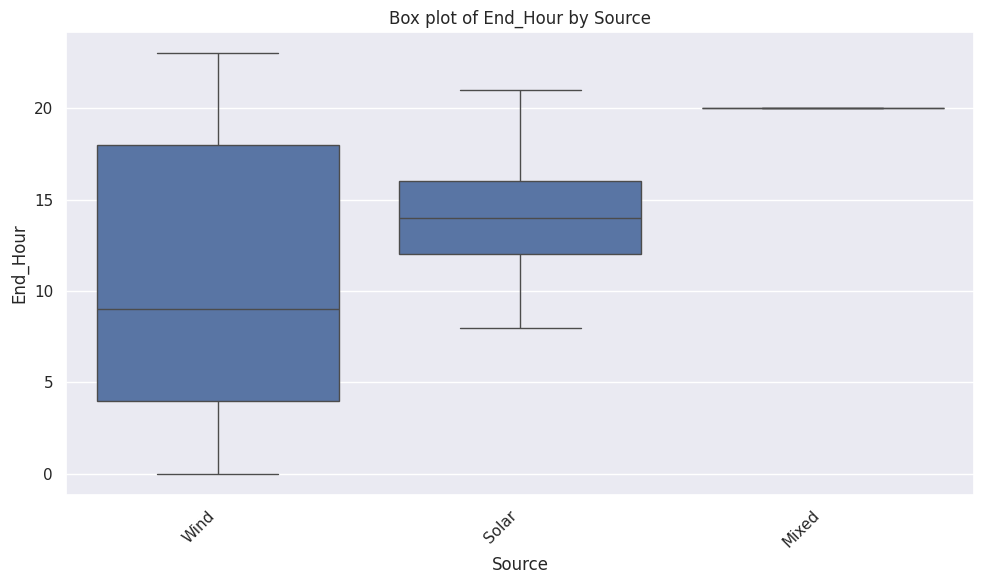

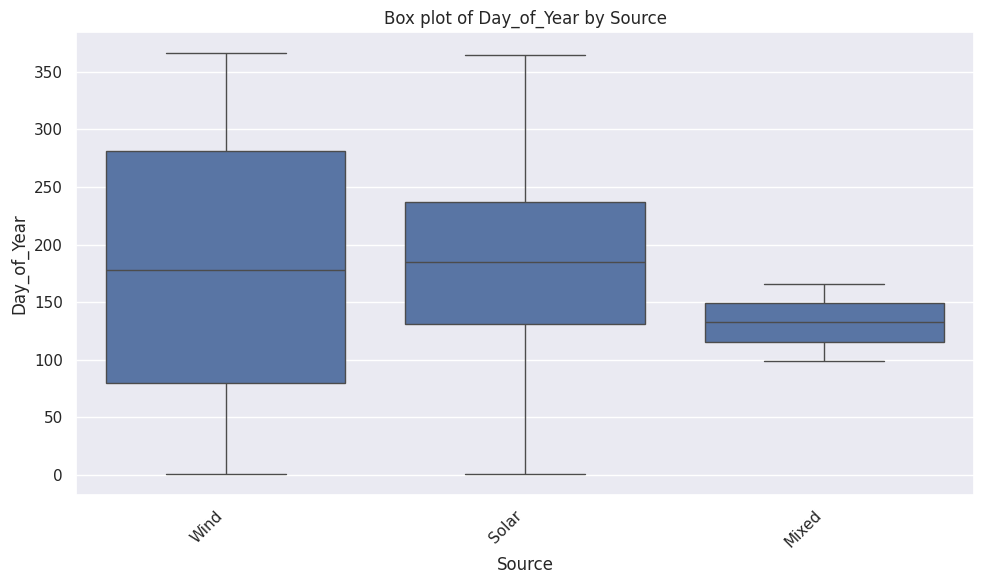

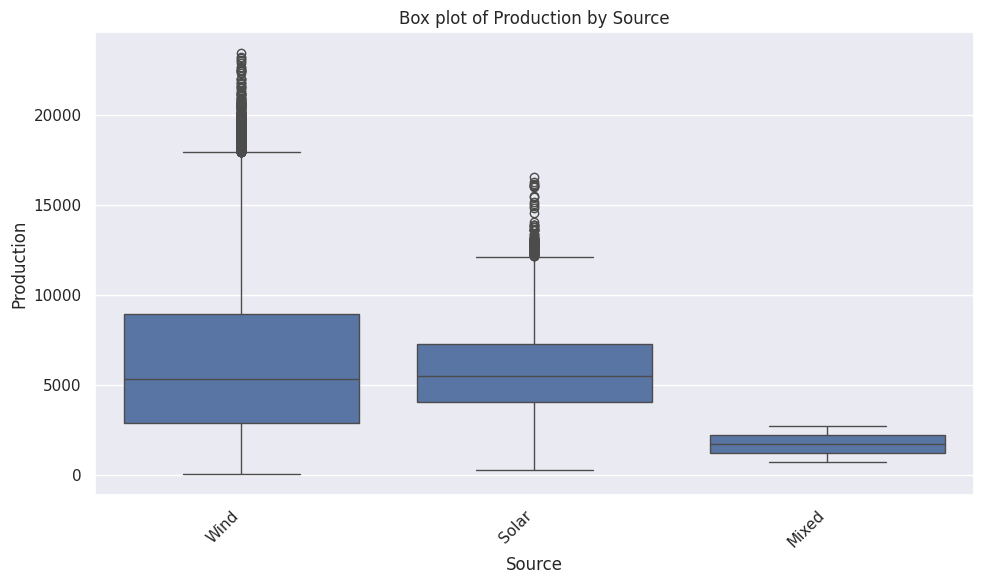

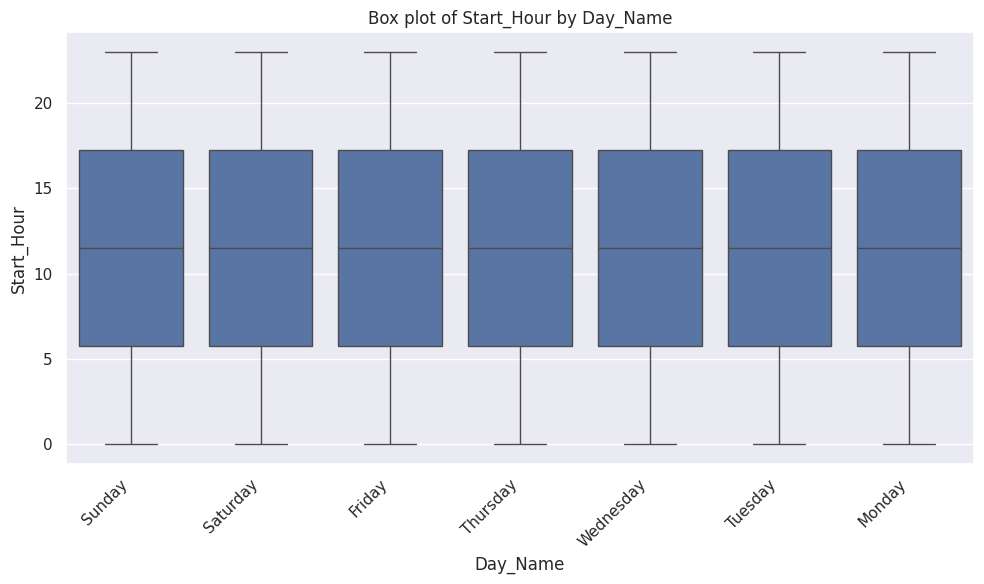

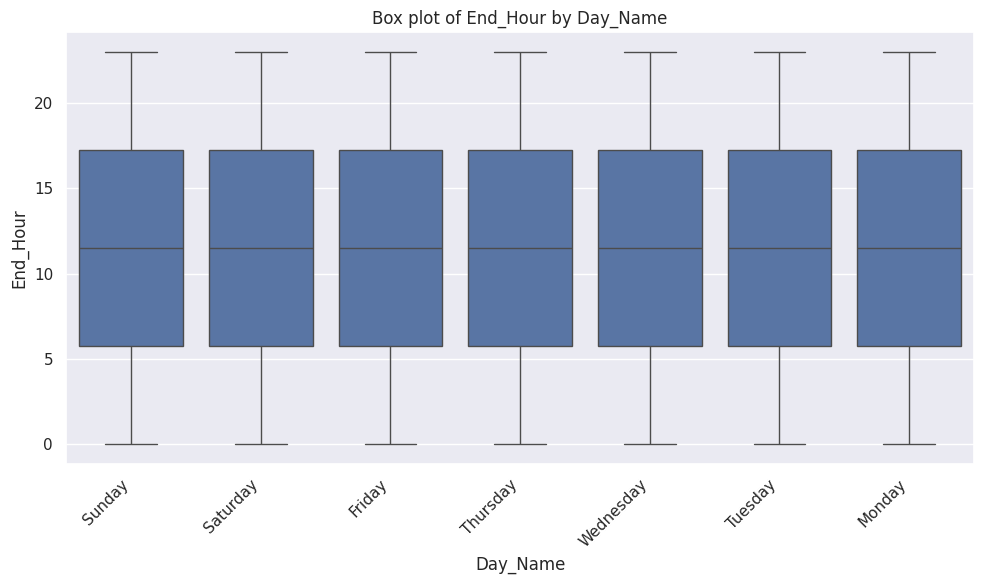

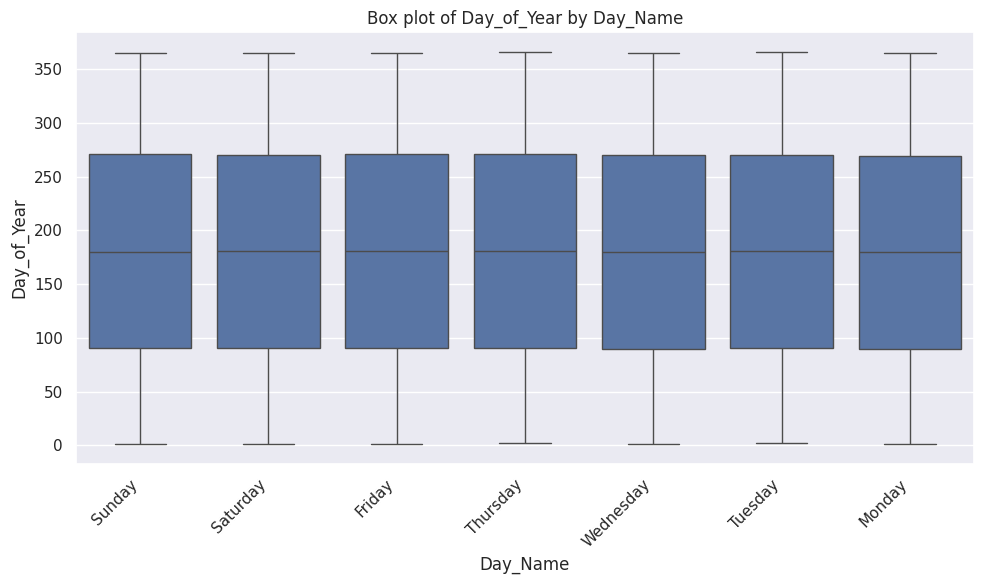

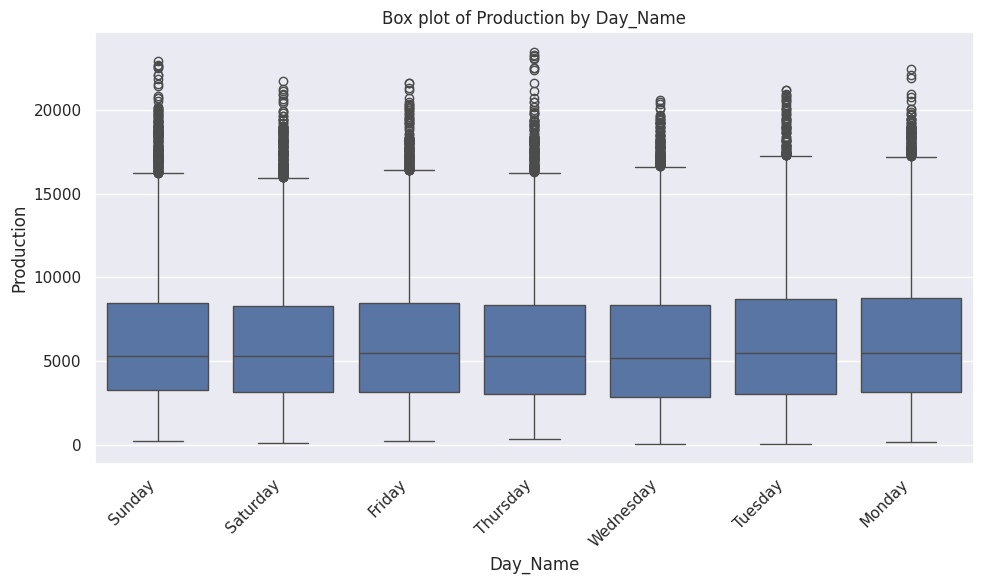

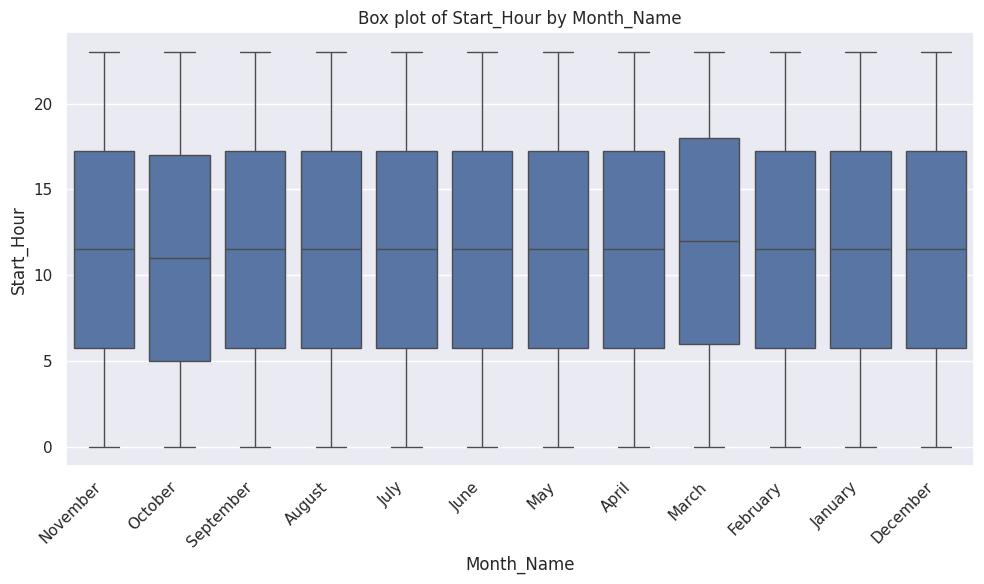

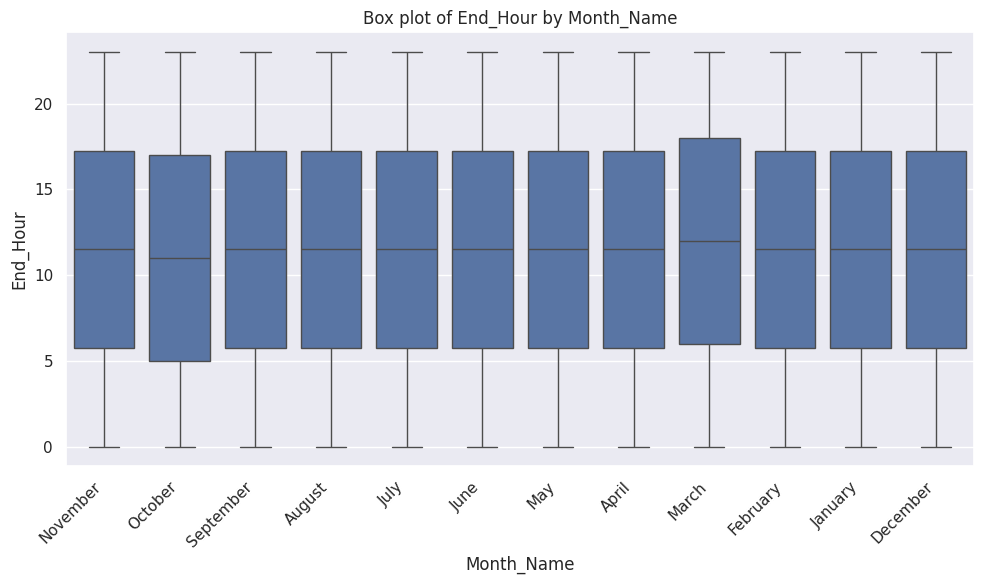

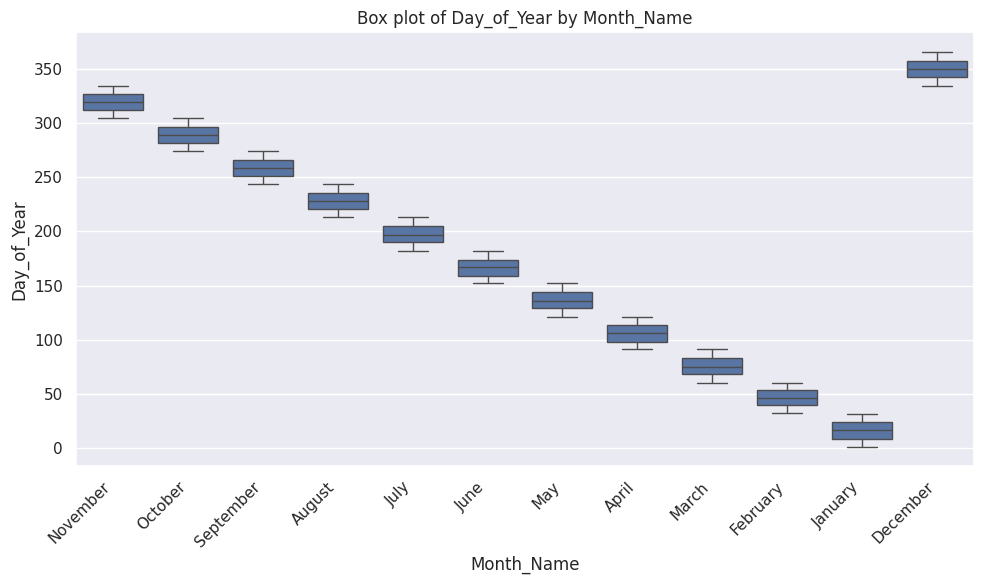

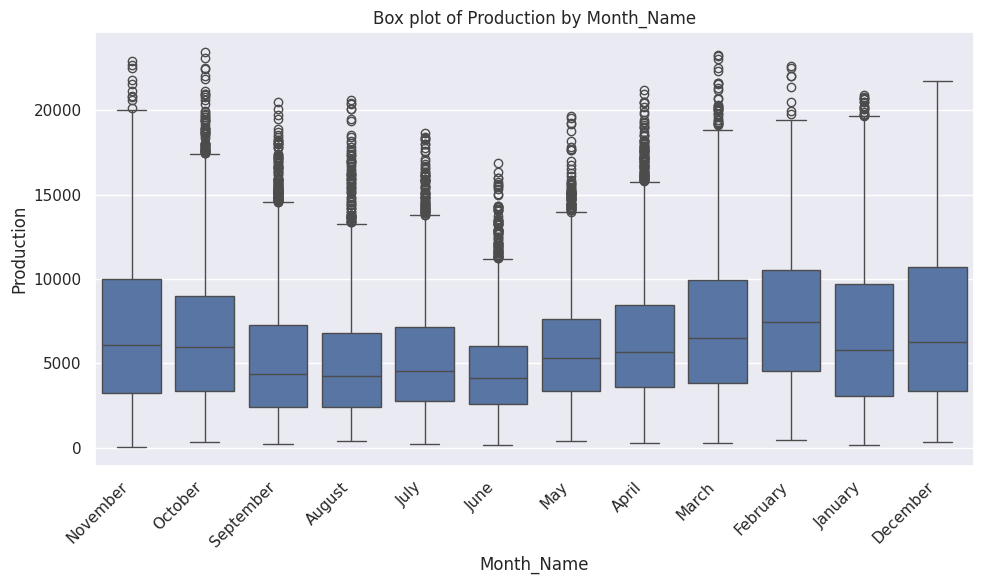

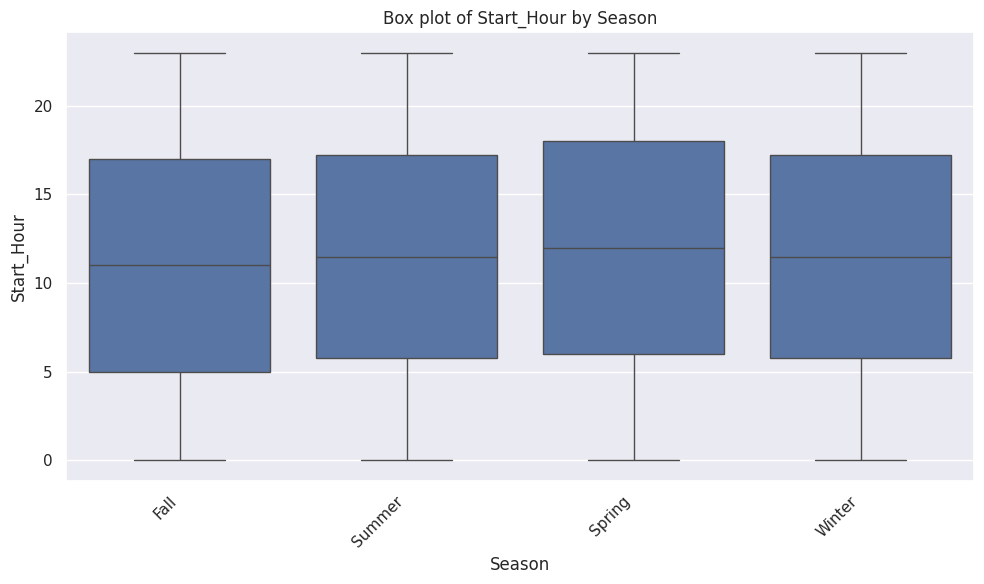

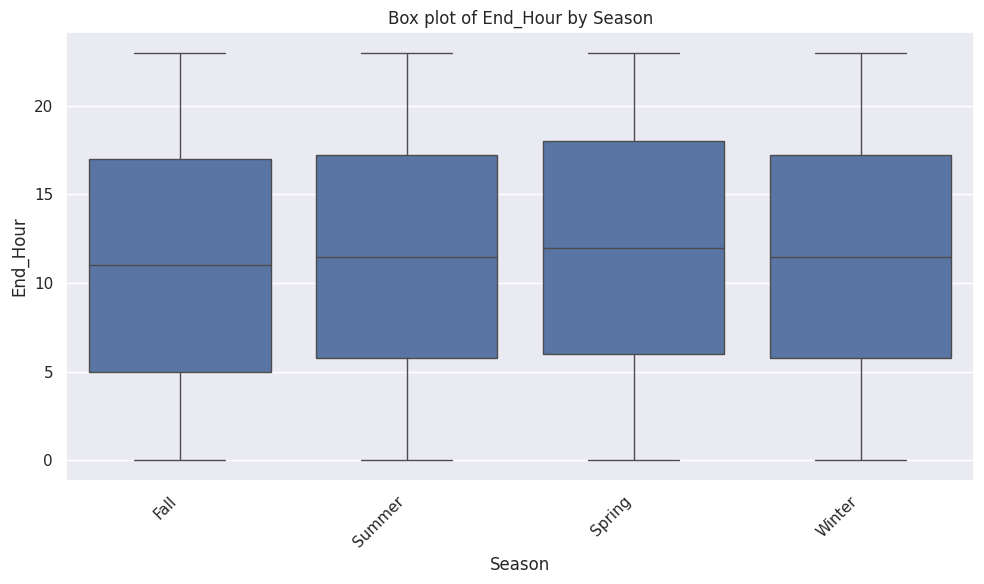

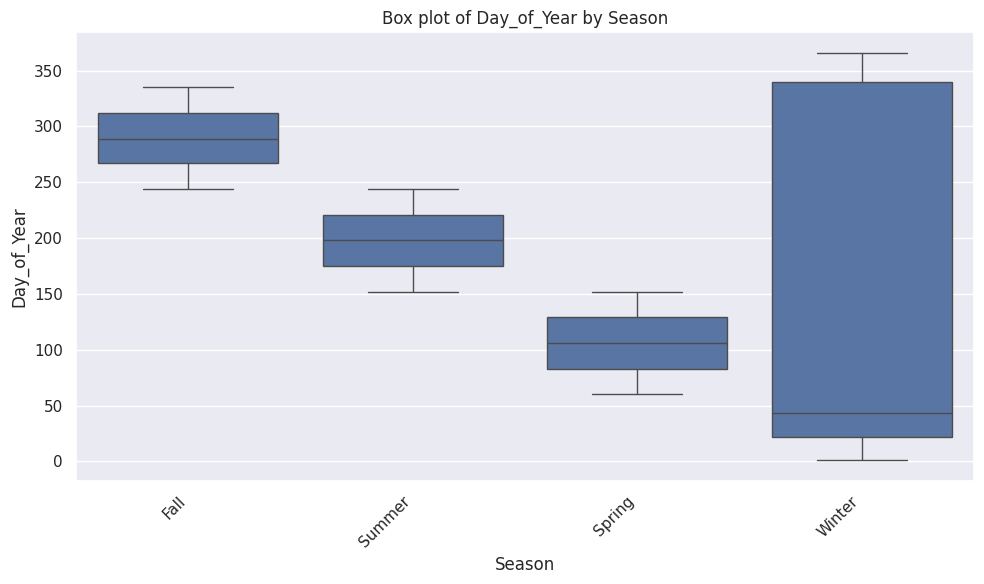

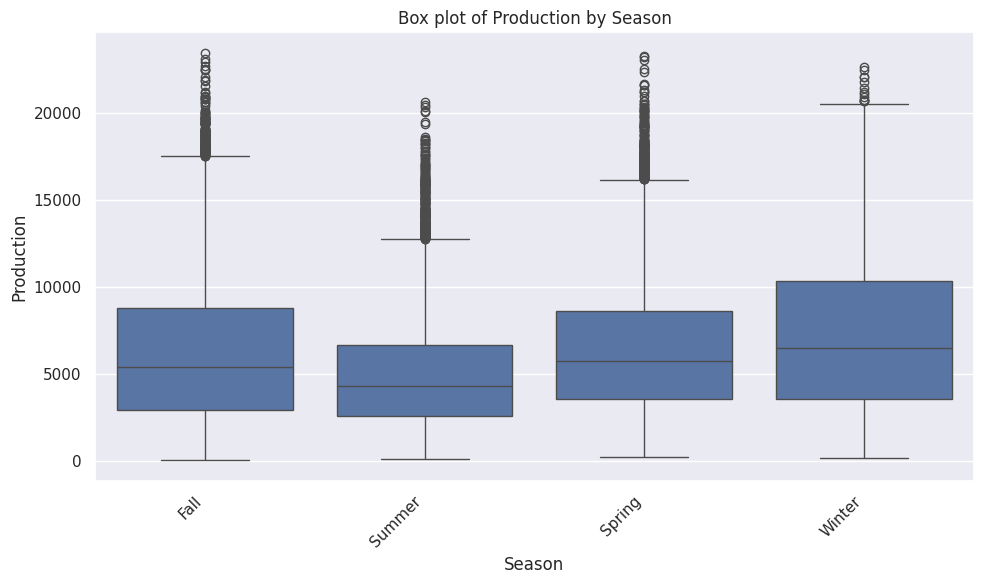

In [11]:
# Numerical-Numerical relationships (Scatter plots)
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through pairs of numerical columns and create scatter plots
for i in range(len(numerical_cols)):
    for j in range(i + 1, len(numerical_cols)):
        col1 = numerical_cols[i]
        col2 = numerical_cols[j]
        plt.figure(figsize=(10, 6))
        sns.scatterplot(data=df, x=col1, y=col2)
        plt.title(f'Scatter plot of {col1} vs {col2}')
        plt.xlabel(col1)
        plt.ylabel(col2)
        plt.show()

# Categorical-Numerical relationships (Box plots)
categorical_cols = df.select_dtypes(include='object').columns.tolist()
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through categorical and numerical columns and create box plots
for cat_col in categorical_cols:
    for num_col in numerical_cols:
        plt.figure(figsize=(10, 6))
        sns.boxplot(data=df, x=cat_col, y=num_col)
        plt.title(f'Box plot of {num_col} by {cat_col}')
        plt.xlabel(cat_col)
        plt.ylabel(num_col)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

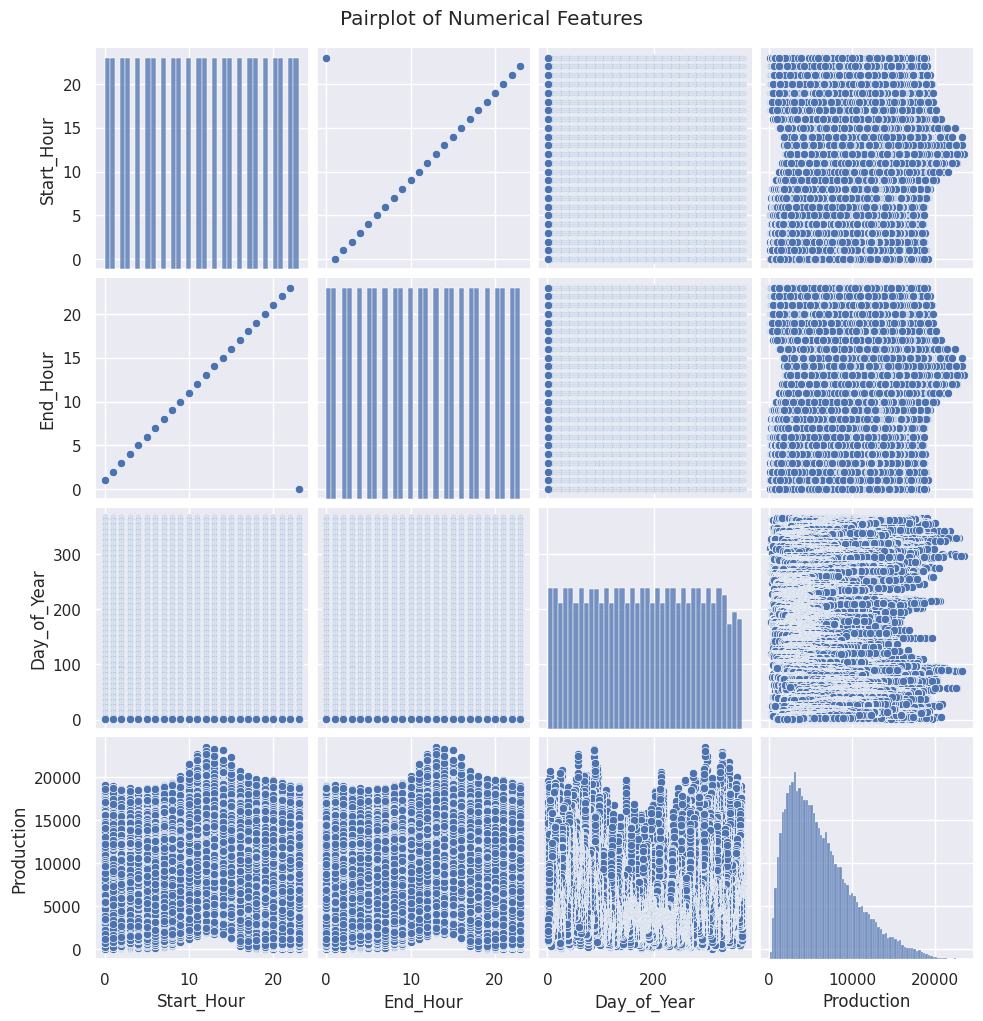

In [12]:
sns.pairplot(df.select_dtypes(include=np.number))
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.show()

## Feature Engineering for Time-Based Analysis


In [22]:
df['Year'] = df['Date'].dt.year
df['Week_of_Year'] = df['Date'].dt.isocalendar().week.astype(int)
df['Is_Weekend'] = df['Day_Name'].isin(['Saturday', 'Sunday'])

print(df[['Date', 'Year', 'Week_of_Year', 'Day_Name', 'Is_Weekend']].head())

        Date  Year  Week_of_Year Day_Name  Is_Weekend
0 2025-11-30  2025            48   Sunday        True
1 2025-11-30  2025            48   Sunday        True
2 2025-11-30  2025            48   Sunday        True
3 2025-11-30  2025            48   Sunday        True
4 2025-11-30  2025            48   Sunday        True


## Analyze 'Source' Distribution and Handle 'Mixed'


In [23]:
print(df['Source'].value_counts())

Source
Wind     42484
Solar     9378
Mixed        2
Name: count, dtype: int64


In [24]:
df_filtered = df[df['Source'] != 'Mixed'].copy()

print(df_filtered['Source'].value_counts())

Source
Wind     42484
Solar     9378
Name: count, dtype: int64


## Visualize Production by Day of Week


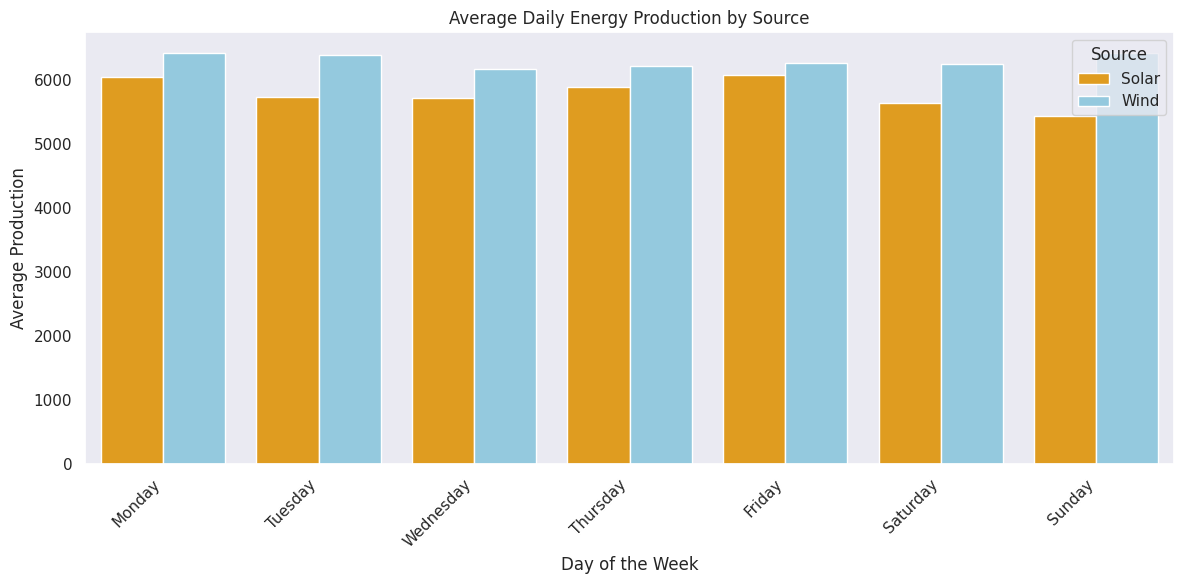

In [25]:
average_daily_production_by_source = df_filtered.groupby(['Day_Name', 'Source'])['Production'].mean().reset_index()

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
average_daily_production_by_source['Day_Name'] = pd.Categorical(average_daily_production_by_source['Day_Name'], categories=day_order, ordered=True)
average_daily_production_by_source = average_daily_production_by_source.sort_values('Day_Name')

plt.figure(figsize=(12, 6))
sns.barplot(data=average_daily_production_by_source, x='Day_Name', y='Production', hue='Source', palette={'Wind': 'skyblue', 'Solar': 'orange'})
plt.title('Average Daily Energy Production by Source')
plt.xlabel('Day of the Week')
plt.ylabel('Average Production')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.tight_layout()
plt.show()


## Compare Seasonal Production Trends


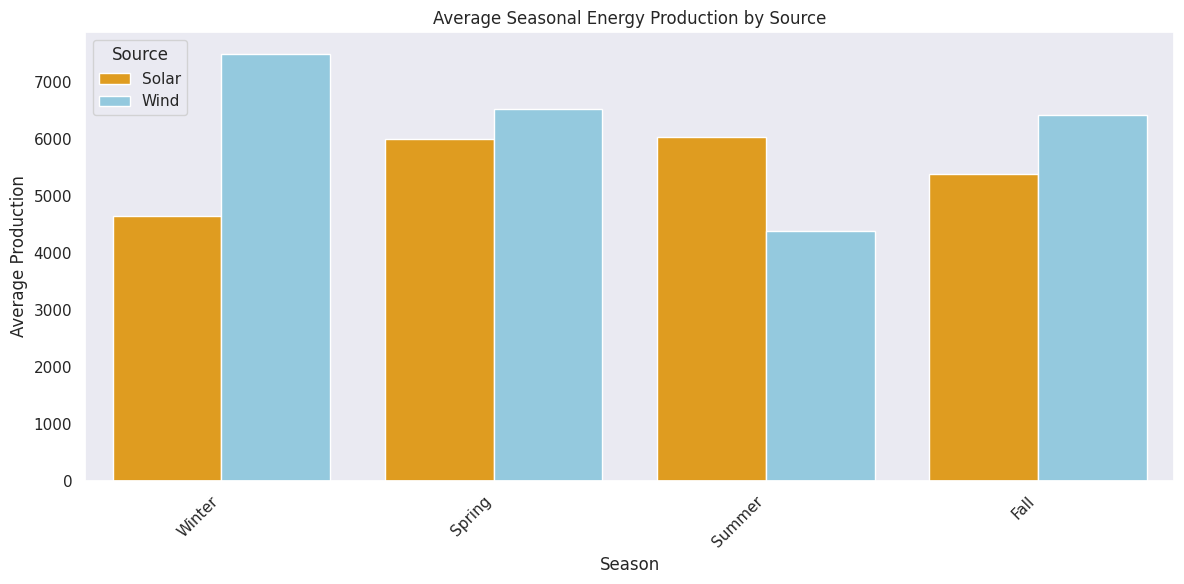

In [26]:
average_seasonal_production_by_source = df_filtered.groupby(['Season', 'Source'])['Production'].mean().reset_index()

season_order = ['Winter', 'Spring', 'Summer', 'Fall']
average_seasonal_production_by_source['Season'] = pd.Categorical(average_seasonal_production_by_source['Season'], categories=season_order, ordered=True)
average_seasonal_production_by_source = average_seasonal_production_by_source.sort_values('Season')

plt.figure(figsize=(12, 6))
sns.barplot(data=average_seasonal_production_by_source, x='Season', y='Production', hue='Source', palette={'Wind': 'skyblue', 'Solar': 'orange'})
plt.title('Average Seasonal Energy Production by Source')
plt.xlabel('Season')
plt.ylabel('Average Production')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

## Detailed Production Distribution and Outlier Check



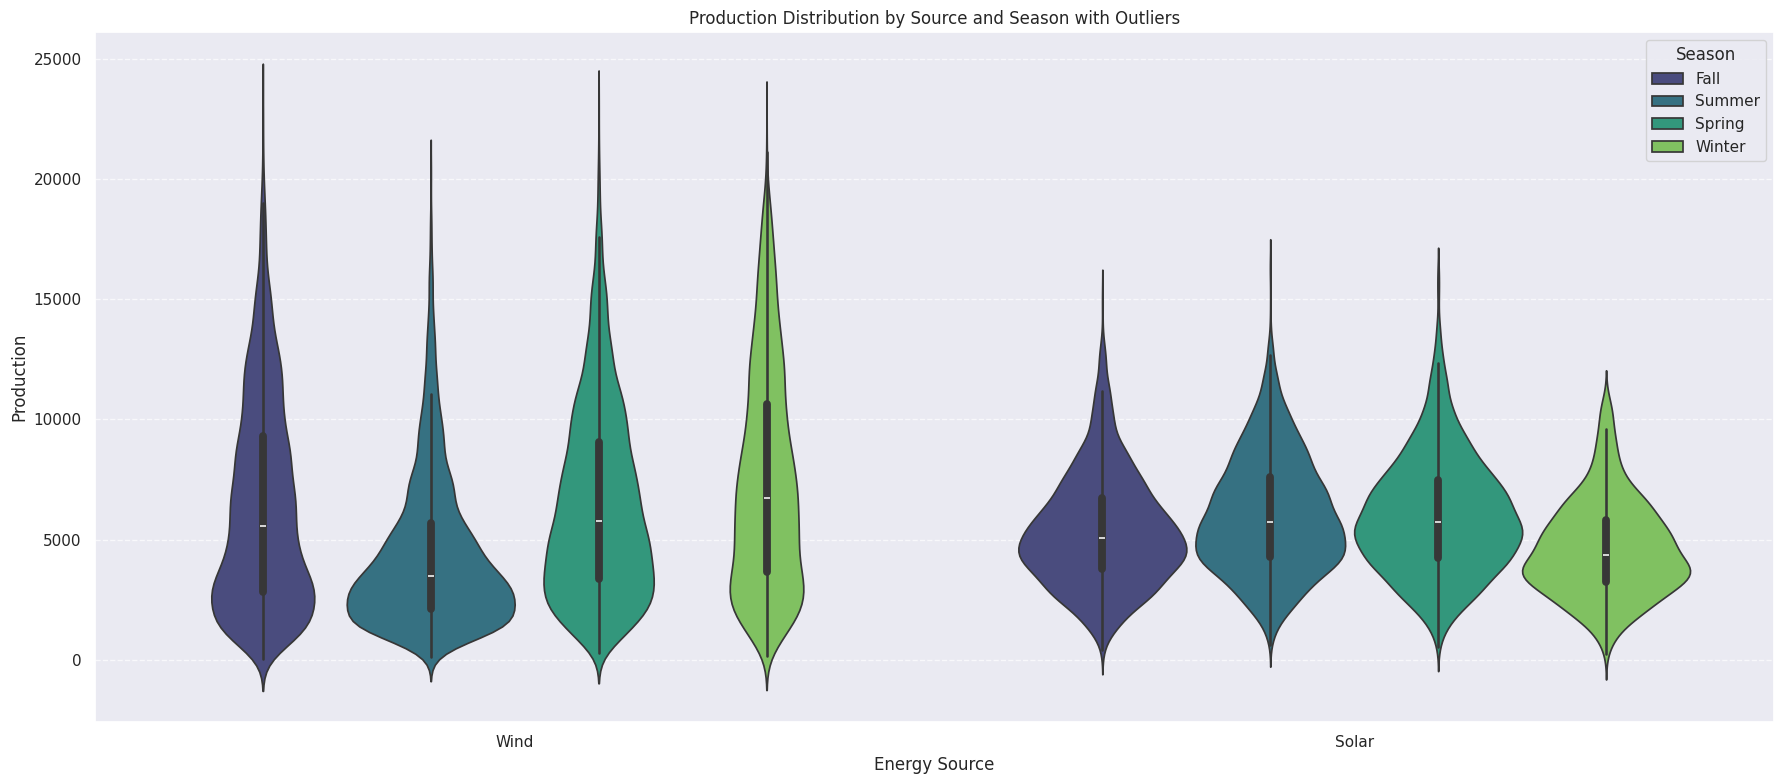

In [27]:
plt.figure(figsize=(18, 8))
sns.violinplot(data=df_filtered, x='Source', y='Production', hue='Season', palette='viridis')
plt.title('Production Distribution by Source and Season with Outliers')
plt.xlabel('Energy Source')
plt.ylabel('Production')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

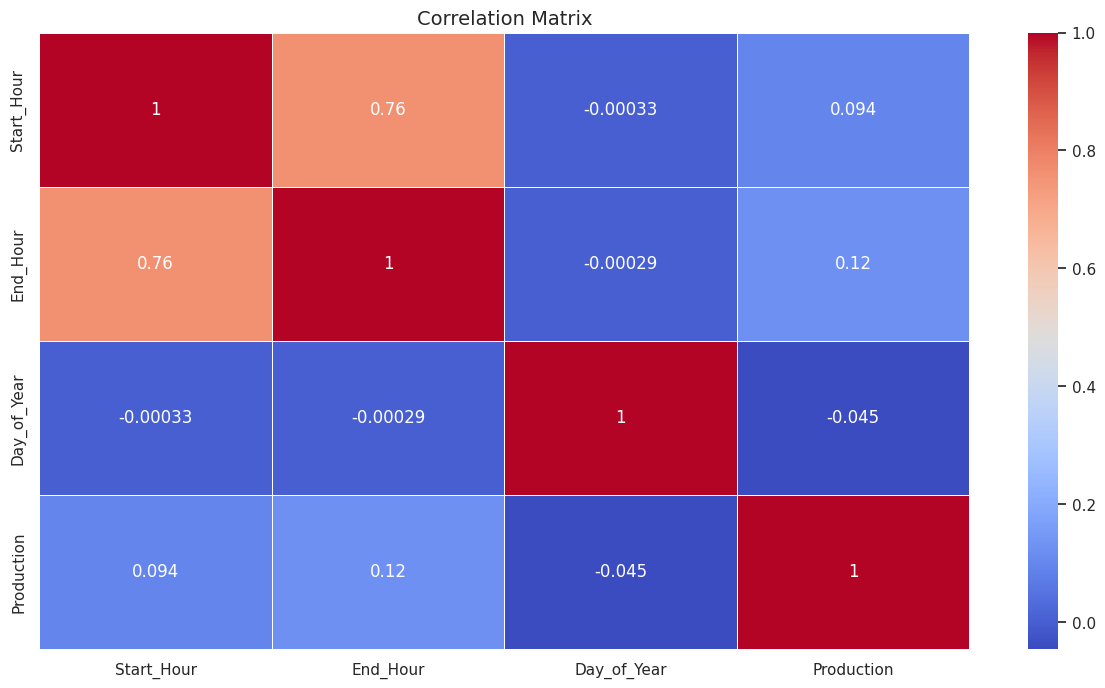

In [13]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.corr(numeric_only = True), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14)
plt.show()

# Thank You